In [ ]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import os
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Input,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score
)
from sklearn.cluster import KMeans

import umap

warnings.filterwarnings('ignore')

In [ ]:
import random

## SETEAMOS SEMILLA

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED) ## ResNet50 , Inception , EfficientNetB2 , Transformer
# from tensorflow.keras.applications import DenseNet121,ResNet50,EfficientNetB0,Xception


## CARGAMOS LA BASE DE DATOS

In [ ]:
# Crear la carpeta .kaggle si no existe
os.makedirs("/root/.kaggle", exist_ok=True)
# Mover el archivo kaggle.json a la carpeta
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# Dar permisos adecuados
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d carloscanamejoy/dataset-spines-complete

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-complete
License(s): apache-2.0
100% 468M/468M [00:31<00:00, 15.6MB/s]



In [ ]:
# Nombre del archivo descargado (ajústalo según sea necesario)
dataset_zip = "/content/dataset-spines-complete.zip"
# Extraer los archivos
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")
# Ver archivos extraídos
os.listdir("dataset")

['dataset-united.npz']

In [ ]:
file_ = '/content/dataset/dataset-united.npz'
data = np.load(file_)

print(data.files)

['img', 'params']


In [ ]:
data['img'].shape

(218256, 39, 39, 1)

In [ ]:
data['params'].shape

(218256, 8)

## PREPROCESAMIENTO

In [ ]:
X = np.copy(data['img'])
y = np.copy(data['params'])

## Definimos set de training, validación y test

In [ ]:
from sklearn.model_selection import train_test_split

# test 15%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# validation 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1765, random_state=42
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

y_train_scaled = scaler.fit_transform(y_train)
y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [ ]:
def preprocess_batch(x):
    x = tf.image.resize(x, (224,224))
    x = tf.image.grayscale_to_rgb(x)
    return x

In [ ]:
BATCH_SIZE = 512

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

## DEFINIMOS EL MODELO RESNET

In [ ]:
# Definir la entrada
input_layer = Input(shape=(224, 224, 3))

# Modelo base
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Pooling global
x = GlobalAveragePooling2D()(base_model.output)

# Capa final de regresión (3 variables)
outputs = Dense(8, activation='linear')(x)

# Modelo final
model = Model(inputs=input_layer, outputs=outputs)

# Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 23,550,984 (89.84 MB)

 Non-trainable params: 53,120 (207.50 KB)

## ENTRENAMIENTO

In [ ]:
EPOCHS = 20

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 156s 340ms/step - loss: 0.0678 - mae: 0.1440 - val_loss: 0.1569 - val_mae: 0.2866 - learning_rate: 0.0010
Epoch 2/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - loss: 0.0258 - mae: 0.1008 - val_loss: 0.1330 - val_mae: 0.2632 - learning_rate: 0.0010
Epoch 3/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - loss: 0.0236 - mae: 0.0939 - val_loss: 0.0882 - val_mae: 0.1977 - learning_rate: 0.0010
Epoch 4/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - loss: 0.0226 - mae: 0.0912 - val_loss: 0.0335 - val_mae: 0.1176 - learning_rate: 0.0010
Epoch 5/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - loss: 0.0218 - mae: 0.0886 - val_loss: 0.0317 - val_mae: 0.1106 - learning_rate: 0.0010
Epoch 6/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 216ms/step - loss: 0.0210 - mae: 0.0867 - val_loss: 0.0253 - val_mae: 0.0953 - learning_rate: 0.0010
Epoch 7/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 216ms/step - loss: 0.0204 - mae: 0.0852 - val_loss: 0.0309 - val_mae: 0.1033 - learni

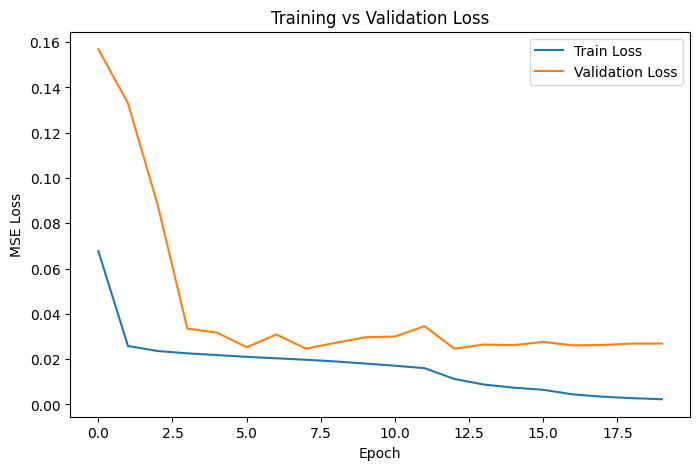

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

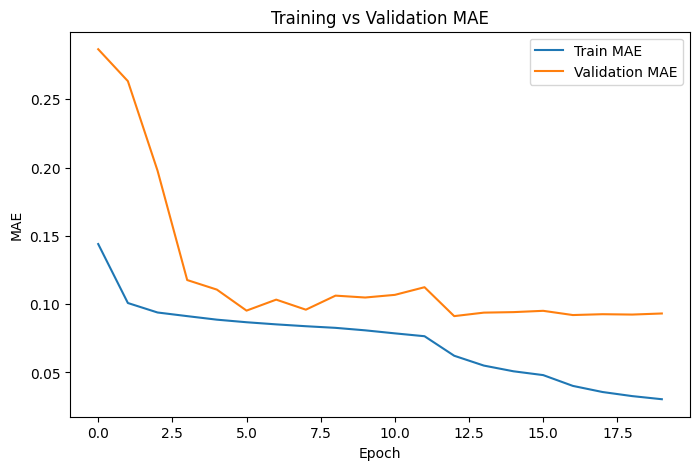

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

## GUARDAMOS LOS PESOS

In [ ]:
model.save('/content/drive/MyDrive/DoctoradoPaper1/modelo_resnet_fulldatabaseV2.h5')